In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , confusion_matrix

In [3]:
data = pd.read_csv('synthetic_text_data.csv')
X = data['text']
y = data['label']

In [4]:
data

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology
...,...,...
80,AI is enhancing customer experiences in retail...,Technology
81,Politicians are debating the pros and cons of ...,Politics
82,Television networks are trying to adapt to the...,Entertainment
83,New wearable technologies are improving health...,Technology


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

In [6]:
X_train

77    Digital currencies and blockchain technology a...
42    Robots and drones are becoming more common in ...
49    The tech industry is seeing increased investme...
11    Political leaders are scrambling to address th...
30    The basketball season is well underway, with t...
                            ...                        
20    Electric vehicles are becoming increasingly po...
60    Artificial intelligence can assist in making c...
71    Hollywood actors are voicing their concerns ab...
14    The latest FIFA tournament was an unforgettabl...
51    Football teams are planning pre-season friendl...
Name: text, Length: 68, dtype: str

In [7]:
y_train

77       Technology
42       Technology
49       Technology
11         Politics
30           Sports
          ...      
20       Technology
60       Technology
71    Entertainment
14           Sports
51           Sports
Name: label, Length: 68, dtype: str

In [9]:
vectorizer = CountVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [10]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [12]:
y_pred = model.predict(X_test_vectorized)
print(accuracy_score(y_test, y_pred))

0.8823529411764706


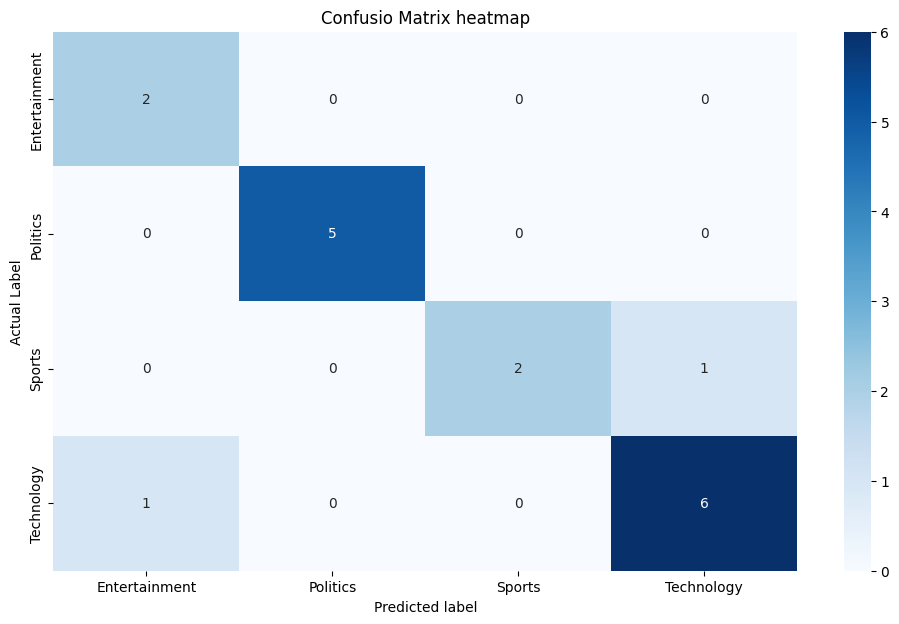

In [17]:
class_lebels = np.unique(y_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (12,7))
sns.heatmap(conf_matrix , annot = True, fmt = 'd', cmap = 'Blues', 
            xticklabels = class_lebels,
            yticklabels = class_lebels)
plt.title('Confusio Matrix heatmap')
plt.xlabel('Predicted label')
plt.ylabel('Actual Label')
plt.show()

In [18]:
user_input = ("I love artificial intelligence and machine learning")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Technology' category.


In [21]:
predicted_label[0]

np.str_('Technology')